In [ ]:
if "BrentScheme" not in locals():
  !pip install "git+https://github.com/perryGabriel/brent-scheme.git"
  from brentscheme import *
import numpy as np
import torch
from tqdm import trange
import pandas as pd
import time
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
scheme = BrentScheme(n=3, d=2, m=4, p=8, verbose=1)
factory = SchemaFactory()
printer = SchemeDisplay()
manipulator = SchemeManipulator()
stepper = Stepper()
trainer = Trainer()

A scheme for (3 x 2) @ (2 x 4) using 8 products: complexity is n^1.963


In [ ]:
# @title File Save/Read Functions

# printer.test(scheme, verbose=0)
# round = lambda x,y:x # needed if dump_to_file throws an error - remember to use number= to avoid a long file name

# Save the scheme to Colab
# manipulator.set_norm(scheme, 2)
# score = printer.dump_to_file(scheme, number = -3.145)
# print(f"Score: {score}")

# Download the file from Colab to your computer. Remember to specify which scheme you want!
# download_file(n=scheme.n, d=scheme.d, m=scheme.m, p=scheme.p, number=score, scheme_or_diagram='scheme')

# Read into locals() a scheme from Colab's files. Remember to specify which scheme you want!
# factory.set_scheme(scheme, 'random', n=3, d=3, m=3, p=22)
# factory.read_from_files(scheme, n=scheme.n, d=scheme.d, m=scheme.m, p=scheme.p, number=-3.130, verbose=2)

# Delete a scheme from Colab. Remember to specify which scheme you want!
# delete_file(n=scheme.n, d=scheme.d, m=scheme.m, p=scheme.p, number=score, scheme_or_diagram='scheme')

In [ ]:
#@title Higher order SVD
def HOSVD(orig):
  Sigma = orig.clone()
  U = []

  for i,size in enumerate(Sigma.size()):
    U.append(None)
    temp = Sigma.transpose(0,i).reshape(size, -1)
    U[i], _, _ = torch.linalg.svd(temp)
    Sigma = (U[i].T @ temp).reshape(Sigma.transpose(0,i).size()).transpose(0,i)

  return Sigma, U

In [ ]:
M = rand_square(3)
Sigma,U = HOSVD(M)
assert torch.allclose(torch.einsum("PN,pP,nN->pn", Sigma, U[0], U[1]), M, rtol=1e-10)
# display(Sigma.round(decimals=4))

T = torch.rand((3,4,5))
Sigma,U = HOSVD(T)
assert torch.allclose(torch.einsum("PND,pP,nN,dD->pnd", Sigma, U[0], U[1], U[2]), T, atol=1e-11, rtol=1e-3)

factory.set_scheme(scheme, 'strassen')
Sigma,U = HOSVD(scheme.alpha_pnd)
assert torch.allclose(torch.einsum("PND,pP,nN,dD->pnd", Sigma, U[0], U[1], U[2]), scheme.alpha_pnd, rtol=1e-10)
# display(torch.einsum("Pnd,pP->pnd", Sigma, U[0]).round(decimals=4))
# display(U[1], U[2])

factory.set_scheme(scheme, 'strassen')
manipulator.change_basis(scheme, L=random_unitary(scheme.n), M=random_unitary(scheme.d), R=random_unitary(scheme.m))
Sigma,U = HOSVD(scheme.TRIPLE_DELTA_nmnddm)
assert torch.allclose(torch.einsum("cCaAbB,cx,CX,ay,AY,bz,BZ->xXyYzZ", Sigma, U[0], U[1], U[2], U[3], U[4], U[5]), scheme.TRIPLE_DELTA_nmnddm, rtol=1e-10)
assert torch.allclose(Sigma, scheme.TRIPLE_DELTA_nmnddm, rtol=1e-10)
Sigma,U = HOSVD(scheme.forward())

Network trained for (2 x 2) @ (2 x 2) using 7 out of 8 multiplications; complexity is n^2.807

Using the L1 norm over the field R

Avg L1 error: 10^-15.4736, Avg L2 error: 10^-15.3689, max error: 10^-14.8754



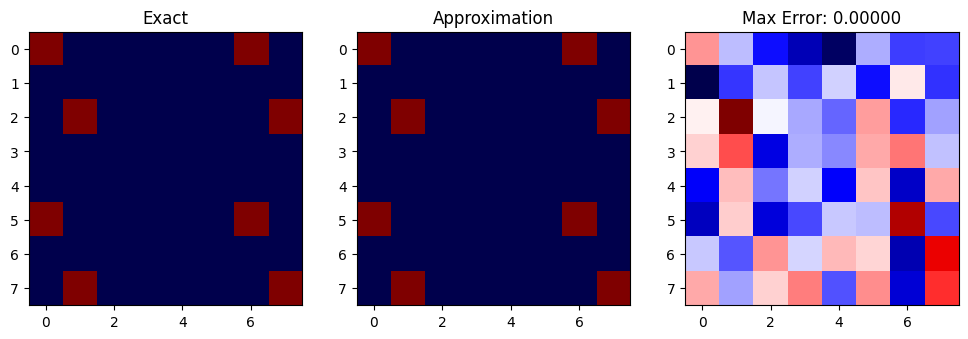


Network trained for (2 x 2) @ (2 x 2) using 7 out of 8 multiplications; complexity is n^2.807

Using the L1 norm over the field R

Avg L1 error: 10^-15.4722, Avg L2 error: 10^-15.3594, max error: 10^-14.8085



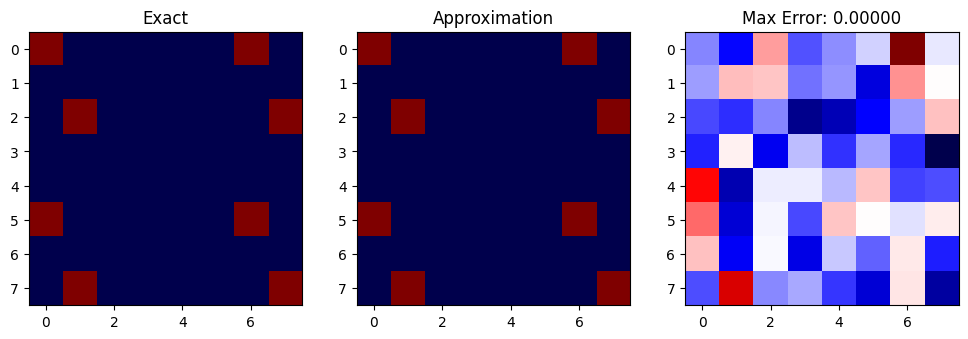

In [ ]:
# factory.set_scheme(scheme, 'random', n=3, d=3, m=3, p=16)
stepper.epoch_pseudoinverse(scheme, batch_size=1000)
printer.print(scheme, verbose=1)
printer.print_triple_deltas(scheme)

Sigma,U = HOSVD(scheme.forward())

# display(U[0])
# display(U[1])
# display(U[2])
# display(U[3]) # close
# display(U[4]) # close
# display(U[5]) # close

# print()

# display(U[0] @ U[2]) # n (gamma @ alpha)
# display(U[1] @ U[5]) # d (gamma @ beta)
# display(U[3] @ U[4]) # m (alpha @ beta)
# each matrix is an involution?

print()

# printer.print_triple_deltas(scheme, output=Sigma.reshape((scheme.n*scheme.m, scheme.n*scheme.d**2*scheme.m)))

manipulator.change_basis(scheme, L=U[2].T, M=U[3].T, R=U[5].T)
# manipulator.round(scheme, 4)
printer.print(scheme, verbose=1)
printer.print_triple_deltas(scheme)